In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download msambare/fer2013

!unzip fer2013.zip -d ./fer2013

print("Dataset downloaded and extracted.")


Streaming output truncated to the last 5000 lines.
  inflating: ./fer2013/train/sad/Training_65267116.jpg  
  inflating: ./fer2013/train/sad/Training_65275626.jpg  
  inflating: ./fer2013/train/sad/Training_6529266.jpg  
  inflating: ./fer2013/train/sad/Training_65329617.jpg  
  inflating: ./fer2013/train/sad/Training_65338712.jpg  
  inflating: ./fer2013/train/sad/Training_65338797.jpg  
  inflating: ./fer2013/train/sad/Training_65387162.jpg  
  inflating: ./fer2013/train/sad/Training_65404494.jpg  
  inflating: ./fer2013/train/sad/Training_65426218.jpg  
  inflating: ./fer2013/train/sad/Training_65430136.jpg  
  inflating: ./fer2013/train/sad/Training_65437377.jpg  
  inflating: ./fer2013/train/sad/Training_6545735.jpg  
  inflating: ./fer2013/train/sad/Training_65463385.jpg  
  inflating: ./fer2013/train/sad/Training_65473985.jpg  
  inflating: ./fer2013/train/sad/Training_65502829.jpg  
  inflating: ./fer2013/train/sad/Training_65505359.jpg  
  inflating: ./fer2013/train/sad/Traini

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_generator = train_datagen.flow_from_directory(
    './fer2013/train',
    target_size=(48,48),
    batch_size=32,
    color_mode='grayscale',
    class_mode='categorical',
    subset='training'
)

validation_generator = train_datagen.flow_from_directory(
    './fer2013/train',
    target_size=(48,48),
    batch_size=32,
    color_mode='grayscale',
    class_mode='categorical',
    subset='validation'
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(48,48,1)),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(7, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history = model.fit(
    train_generator,
    epochs=30,
    validation_data=validation_generator
)










Found 22968 images belonging to 7 classes.
Found 5741 images belonging to 7 classes.


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


718/718 ━━━━━━━━━━━━━━━━━━━━ 21s 22ms/step - accuracy: 0.2439 - loss: 1.8200 - val_accuracy: 0.3696 - val_loss: 1.5862
Epoch 2/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.3787 - loss: 1.5876 - val_accuracy: 0.4532 - val_loss: 1.4394
Epoch 3/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.4473 - loss: 1.4426 - val_accuracy: 0.4818 - val_loss: 1.3435
Epoch 4/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.4852 - loss: 1.3522 - val_accuracy: 0.5015 - val_loss: 1.2892
Epoch 5/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.5072 - loss: 1.2859 - val_accuracy: 0.5159 - val_loss: 1.2694
Epoch 6/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.5185 - loss: 1.2535 - val_accuracy: 0.5280 - val_loss: 1.2378
Epoch 7/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.5438 - loss: 1.1973 - val_accuracy: 0.5318 - val_loss: 1.2333
Epoch 8/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.5602 - loss: 1.1570 - val_accurac

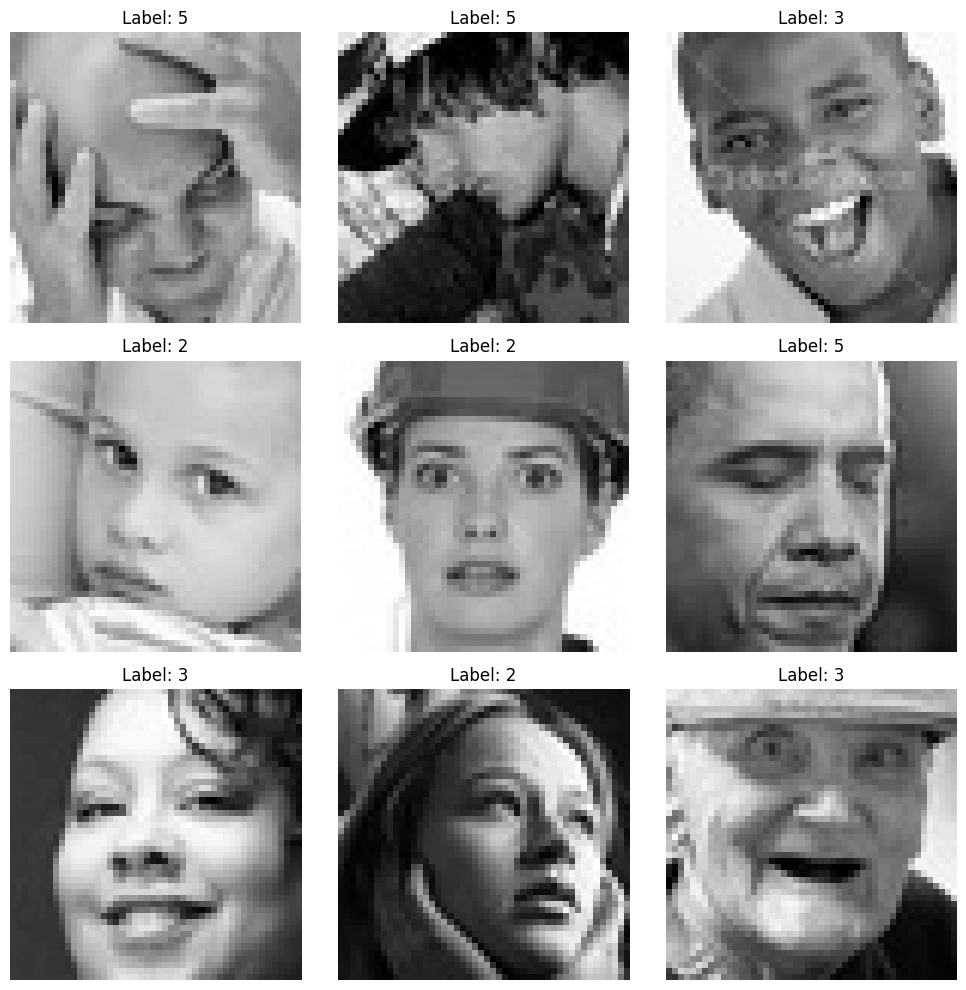

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

images, labels = next(train_generator)

plt.figure(figsize=(10,10))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i].reshape(48,48), cmap='gray')
    plt.title(f"Label: {np.argmax(labels[i])}")
    plt.axis('off')
plt.tight_layout()
plt.show()


In [ ]:
for batch_imgs, _ in train_generator:
    model(batch_imgs)
    break

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 46, 46, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 21, 21, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,067,543 (4.07 MB)

 Trainable params: 355,847 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 711,696 (2.71 MB)

Found 22968 images belonging to 7 classes.
Found 5741 images belonging to 7 classes.
Epoch 1/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 16s 18ms/step - accuracy: 0.2421 - loss: 1.8382 - val_accuracy: 0.3243 - val_loss: 1.6868
Epoch 2/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.3389 - loss: 1.6534 - val_accuracy: 0.4229 - val_loss: 1.4897
Epoch 3/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.4202 - loss: 1.4860 - val_accuracy: 0.4571 - val_loss: 1.3904
Epoch 4/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.4629 - loss: 1.3777 - val_accuracy: 0.4964 - val_loss: 1.3161
Epoch 5/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.4953 - loss: 1.3145 - val_accuracy: 0.5060 - val_loss: 1.2814
Epoch 6/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.5205 - loss: 1.2558 - val_accuracy: 0.5212 - val_loss: 1.2501
Epoch 7/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.5373 - loss: 1.2219 - val_accuracy: 0.5375 - val_loss: 1.2276
Epoch

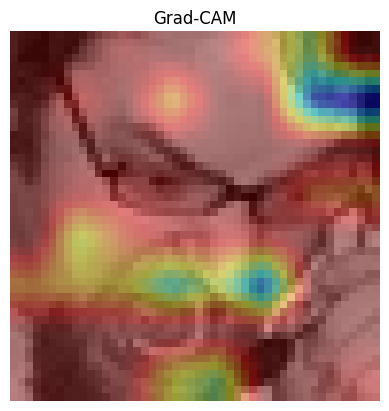

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.models import Model
import cv2
import matplotlib.pyplot as plt

train_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_generator = train_datagen.flow_from_directory(
    './fer2013/train',
    target_size=(48,48),
    batch_size=32,
    color_mode='grayscale',
    class_mode='categorical',
    subset='training'
)

validation_generator = train_datagen.flow_from_directory(
    './fer2013/train',
    target_size=(48,48),
    batch_size=32,
    color_mode='grayscale',
    class_mode='categorical',
    subset='validation'
)

inputs = Input(shape=(48,48,1))
x = Conv2D(32, (3,3), activation='relu', name='conv2d_0')(inputs)
x = MaxPooling2D(2,2)(x)
x = Conv2D(64, (3,3), activation='relu', name='conv2d_1')(x)
x = MaxPooling2D(2,2)(x)
x = Conv2D(128, (3,3), activation='relu', name='conv2d_2')(x)
x = MaxPooling2D(2,2)(x)
x = Flatten()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
outputs = Dense(7, activation='softmax')(x)

model = Model(inputs, outputs)

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history = model.fit(
    train_generator,
    epochs=30,
    validation_data=validation_generator
)

def preprocess_image(img_path):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (48, 48))
    img = img.astype('float32') / 255.0
    img_expanded = np.expand_dims(img, axis=-1)
    img_expanded = np.expand_dims(img_expanded, axis=0)
    return img, img_expanded

def make_gradcam_heatmap(img_array, model, last_conv_layer_name='conv2d_2', pred_index=None):
    grad_model = tf.keras.models.Model(
        inputs=model.input,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

def display_gradcam(img, heatmap):
    heatmap_resized = cv2.resize(heatmap, (48, 48))
    heatmap_resized = np.uint8(255 * heatmap_resized)
    heatmap_color = cv2.applyColorMap(heatmap_resized, cv2.COLORMAP_JET)
    img_color = cv2.cvtColor(np.uint8(img * 255), cv2.COLOR_GRAY2BGR)
    superimposed_img = cv2.addWeighted(img_color, 0.6, heatmap_color, 0.4, 0)
    plt.imshow(superimposed_img)
    plt.axis('off')
    plt.title('Grad-CAM')
    plt.show()

img_path = '/content/fer2013/test/angry/PrivateTest_10131363.jpg'
original_img, processed_img = preprocess_image(img_path)

_ = model.predict(processed_img)

heatmap = make_gradcam_heatmap(processed_img, model, 'conv2d_2')
display_gradcam(original_img, heatmap)


In [ ]:
!pip install ultralytics --quiet

from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 28.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 90.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 67.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 51.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 109.9 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralyt

In [ ]:
import os
import cv2
import shutil

dataset_path = '/content/fer2013_data'  # عدلي ده حسب مكان الداتا عندك
images_dir = os.path.join(dataset_path, 'images_temp')  # تعديل هنا
labels_dir = os.path.join(dataset_path, 'labels_temp')  # تعديل هنا

os.makedirs(images_dir, exist_ok=True)
os.makedirs(labels_dir, exist_ok=True)

emotions = ['angry', 'disgust', 'fear', 'happy', 'sad', 'surprise', 'neutral']

def convert_to_yolo_format(image_path, label, image_size=(48, 48)):
    img = cv2.imread(image_path)
    if img is None:
        print(f"تعذر قراءة الصورة: {image_path}")
        return
    h, w, _ = img.shape

    x_center = 0.5
    y_center = 0.5
    width = 1.0
    height = 1.0

    class_id = emotions.index(label)

    yolo_format = f"{class_id} {x_center} {y_center} {width} {height}"

    label_file = os.path.join(labels_dir, label, os.path.splitext(os.path.basename(image_path))[0] + '.txt')
    os.makedirs(os.path.dirname(label_file), exist_ok=True)

    with open(label_file, 'w') as f:
        f.write(yolo_format)

    destination_image_path = os.path.join(images_dir, label, os.path.basename(image_path))
    os.makedirs(os.path.dirname(destination_image_path), exist_ok=True)
    shutil.copy(image_path, destination_image_path)

def process_images():
    for emotion in emotions:
        emotion_path = os.path.join(dataset_path, 'train', emotion)

        if os.path.exists(emotion_path):
            for img_name in os.listdir(emotion_path):
                img_path = os.path.join(emotion_path, img_name)

                if img_name.lower().endswith(('.jpg', '.png')):
                    convert_to_yolo_format(img_path, emotion)

process_images()

print("convert to yolo format successfully")


convert to yolo format successfully


In [ ]:
yaml_content = """
train: /content/fer2013_data/images/train
val: /content/fer2013_data/images/val

nc: 7
names: ['angry', 'disgust', 'fear', 'happy', 'sad', 'surprise', 'neutral']
"""

with open("data.yaml", "w") as f:
    f.write(yaml_content)

print("create file of data.yaml successfully")


create file of data.yaml successfully


In [ ]:
!pip install facenet-pytorch --quiet

import torch
from facenet_pytorch import MTCNN
import os
from PIL import Image
import cv2

mtcnn = MTCNN(keep_all=False, device='cuda' if torch.cuda.is_available() else 'cpu')

base_dir = '/content/fer2013'
output_dir = '/content/fer2013_data/images_temp'
os.makedirs(output_dir, exist_ok=True)

emotions = ['angry', 'disgust', 'fear', 'happy', 'sad', 'surprise', 'neutral']

for emotion in emotions:
    emotion_path = os.path.join(base_dir, 'train', emotion)
    output_emotion_path = os.path.join(output_dir, emotion)
    os.makedirs(output_emotion_path, exist_ok=True)

    for filename in os.listdir(emotion_path):
        img_path = os.path.join(emotion_path, filename)
        img = Image.open(img_path).convert('RGB')
        face = mtcnn(img)

        if face is not None:
            save_path = os.path.join(output_emotion_path, filename)
            face_img = (face.permute(1, 2, 0).numpy() * 255).astype('uint8')
            cv2.imwrite(save_path, cv2.cvtColor(face_img, cv2.COLOR_RGB2BGR))



KeyboardInterrupt: 

In [ ]:
import os

label_base = '/content/fer2013_data/labels_temp'
image_base = '/content/fer2013_data/images_temp'
os.makedirs(label_base, exist_ok=True)

for idx, emotion in enumerate(emotions):
    emotion_img_path = os.path.join(image_base, emotion)
    emotion_label_path = os.path.join(label_base, emotion)
    os.makedirs(emotion_label_path, exist_ok=True)

    for filename in os.listdir(emotion_img_path):
        if filename.endswith('.jpg') or filename.endswith('.png'):
            label_file = os.path.join(emotion_label_path, filename.replace('.jpg', '.txt').replace('.png', '.txt'))
            with open(label_file, 'w') as f:
                f.write(f"{idx} 0.5 0.5 1.0 1.0\n")  # البوكس يغطي كل الصورة
